# **Formatos de Armazenamento**

**Pesquisas e implementações sobre tipos de arquivos utilizados na análise de dados**

## Dataset Utilizado

**Fonte:** IBGE — Instituto Brasileiro de Geografia e Estatística  
**Link:** [Base Municipal IBGE — repositório do projeto](https://github.com/raimundoivy/pad_avaliacao_02)

| Atributo | Detalhe |
|---|---|
| **Finalidade** | Conjunto de indicadores socioeconômicos e agrícolas de municípios brasileiros — combina dados de safras lavouristas, estabelecimentos agrícolas, educação rural e população |
| **Volume de dados** | **4 252 902 linhas × 13 colunas** (~396 MB em CSV bruto) |
| **Período** | 1974 – 2024 (ano-referência das safras) |
| **Tipo dos dados** | inteiros (`codigo_municipio`, `numero_de_tratores_em_uso`), floats (`populacao_total`, `area_colhida_em_hectares`, `area_total_agricola_em_hectares`), strings (`nome_municipio`, `sigla_estado`, `produto_agricola`, `dependencia_administrativa`), floats derivados (`nivel_geografico`, `matriculas_ensino_medio_rural`, `total_estabelecimentos_agricolas`) |
| **Colunas** | `codigo_municipio`, `nivel_geografico`, `sigla_estado`, `nome_municipio`, `ano_referencia`, `produto_agricola`, `area_colhida_em_hectares`, `dependencia_administrativa`, `matriculas_ensino_medio_rural`, `populacao_total`, `total_estabelecimentos_agricolas`, `area_total_agricola_em_hectares`, `numero_de_tratores_em_uso` |
| **Construção** | Consolidado a partir de 4 fontes IBGE (Censo Agropecuário, PAMS, Matrículas Rurais, Estimativas Populacionais) através de pipeline ETL em `notebooks/pad_avaliacao_02.ipynb` |


Origem/Histórico - Estrutura - Encoding - Compressão

In [1]:
import os
import time
import psutil
import pathlib
import pandas as pd
import polars as pl
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.orc as orc
import fastavro
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
import warnings

In [2]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
os.makedirs("output_formats", exist_ok=True)

In [3]:
master_csv = "dados/master_municipios_tratado.csv"

In [4]:
def get_size_mb(p):
    path = pathlib.Path(p)
    if path.is_dir():
        return sum(f.stat().st_size for f in path.rglob("*") if f.is_file()) / 1e6
    return path.stat().st_size / 1e6 if path.exists() else 0.0


results = []
workflow_start = time.time()

In [5]:
proc = psutil.Process()

print(f"Configuração concluída. Usando a fonte CSV: {master_csv}")


def _t(fn):
    s = time.time()
    fn()
    return time.time() - s

Configuração concluída. Usando a fonte CSV: dados/master_municipios_tratado.csv


In [6]:
df_polars = (
    pl.scan_csv(master_csv, ignore_errors=True)
    .select(["codigo_municipio", "nome_municipio", "sigla_estado", "populacao_total"])
    .drop_nulls()
    .collect()
)

In [7]:
df_pandas = df_polars.to_pandas()

In [8]:
# Justificativa estrutural:
# O formato SequenceFile é estritamente aderente ao ecossistema HDFS/MapReduce na JVM.
# A sua leitura/escrita via Python exige overhead significativo pelo Py4J e um cluster persistente do Hadoop configurado.
# A dependência exclusiva de Writable Classes da JVM impede manipulações atômicas performáticas
# locais (zero-copy) em bibliotecas como Polars e PyArrow.
# O teste abaixo simula a criação mínima utilizando a sessão PySpark em RAM para validar a integração,
# mas não será agregado nas rotinas analíticas finais dos plots gráficos.

import os, psutil

for p in psutil.process_iter(["name"]):
    if p.info["name"] and "java" in p.info["name"].lower():
        try:
            p.kill()
        except:
            pass

try:
    from pyspark.sql import SparkSession

    spark = SparkSession.builder.enableHiveSupport().getOrCreate()
    spark.createDataFrame(df_pandas.head(10)).createOrReplaceTempView("tv")
    spark.sql("DROP TABLE IF EXISTS cs")
    spark.sql("CREATE TABLE cs STORED AS SEQUENCEFILE AS SELECT * FROM tv")
    print("SequenceFile (Try) OK")
except Exception:
    print(
        "SequenceFile ignorado nos resultados finais: Overhead do ecossistema JVM estrito."
    )

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/22 18:52:20 WARN Utils: Your hostname, raimundoivy-750XGL, resolves to a loopback address: 127.0.1.1; using 192.168.15.79 instead (on interface wlo1)
26/03/22 18:52:20 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/22 18:52:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/22 18:52:32 WARN ObjectStore: Version information not found in metastore. hive.metastore.schema.verification is not enabled so recording the schema version 2.3.0
26/03/22 18:52:32 WARN ObjectStore: setMetaStoreSchemaVersion called but recording version is disabled: version = 2.3.0, comment = Set by MetaStore raimu

SequenceFile (Try) OK


In [9]:
avro_schema = {
    "type": "record",
    "name": "root",
    "fields": [
        {"name": "codigo_municipio", "type": ["null", "long"]},
        {"name": "nome_municipio", "type": ["null", "string"]},
        {"name": "sigla_estado", "type": ["null", "string"]},
        {"name": "populacao_total", "type": ["null", "string"]},
    ],
}
print(f"Workflow preparado com {len(df_pandas)} rows.")

Workflow preparado com 4252902 rows.


**1 – Baseados em Texto**

**CSV (Comma-Separated Values)** — Formato texto tabelar simples, amplamente usado em planilhas e bancos de dados desde os anos 1970–1980. Sem esquema formal, sem compressão nativa, sem tipos de dados definidos.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Linhas de texto separadas por delimitador (vírgula/ponto-e-vírgula); cabeçalho opcional na 1ª linha |
| **Encoding** | Texto puro UTF-8; sem serialização binária |
| **Compressão** | Nenhuma nativa; pode-se aplicar gzip/zip externamente |
| **Ponto forte** | Máxima portabilidade e legibilidade humana; suporte universal |
| **Ponto fraco** | Sem tipos, sem schema, sem compressão — ineficiente para Big Data |

**Referências:** [RFC 4180 — CSV Format](https://www.ietf.org/rfc/rfc4180.txt) | [Formatos Suportados — Azure Synapse](https://learn.microsoft.com/pt-pt/previous-versions/azure/synapse-analytics/data-explorer/ingest-data/data-explorer-ingest-data-supported-formats)

In [10]:
p = "output_formats/data_csv.csv"
m0 = proc.memory_info().rss

results.append(
    {
        "Format": "CSV",
        "Compression": "Original",
        "Write Time (s)": _t(lambda: df_polars.write_csv(p)),
        "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
        "Read Time (s)": _t(lambda: pl.read_csv(p, ignore_errors=True)),
        "Meta Time (s)": _t(lambda: pl.read_csv(p, n_rows=1, ignore_errors=True)),
        "Col Time (s)": _t(
            lambda: pl.read_csv(
                p, columns=["codigo_municipio", "populacao_total"], ignore_errors=True
            )
        ),
        "Size (MB)": get_size_mb(p),
    }
)
print(f"✔️ CSV OK — shape: {df_polars.shape}")

✔️ CSV OK — shape: (4252902, 4)


**XML (Extensible Markup Language)** — Formato de marcação derivado do SGML (ISO 8879), criado pelo W3C em 1996. Estrutura hierárquica com tags explícitas. Muito usado em configurações, SOAP e troca de dados legada.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Árvore hierárquica de elementos com tags de abertura/fechamento e atributos |
| **Encoding** | Texto UTF-8/UTF-16; verboso por natureza (tags repetidas por registro) |
| **Compressão** | Minificação (remove espaços); gzip/Brotli externos; EXI (Efficient XML Interchange) binário W3C |
| **Ponto forte** | Autodescritivo, validável via XSD/DTD, suporte a namespaces e dados hierárquicos complexos |
| **Ponto fraco** | Extremamente verboso → arquivos grandes; parsing custoso comparado a JSON/binários |

**Referências:** [W3C XML](https://www.w3.org/XML/) | [W3C XML Activity](https://www.w3.org/XML/Activity) | [W3C XML Notes](https://www.w3.org/XML/notes.html) | [W3C XML Data Model](https://www.w3.org/XML/Datamodel.html) | [W3C XML Structure Theory](https://www.w3.org/XML/9711theory/xmlstruct.html)

In [11]:
p, mult = "output_formats/data_xml.xml", len(df_pandas) / 100000
df_a = df_pandas.head(100000)
m0 = proc.memory_info().rss

results.append(
    {
        "Format": "XML (Est.)",
        "Compression": "Original",
        "Write Time (s)": _t(lambda: df_a.to_xml(p, index=False, parser="etree"))
        * mult,
        "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6) * mult,
        "Read Time (s)": _t(lambda: pd.read_xml(p)) * mult,
        "Meta Time (s)": _t(lambda: pd.read_xml(p, xpath="./*[1]")) * mult,
        "Col Time (s)": _t(
            lambda: pd.read_xml(p)[["codigo_municipio", "populacao_total"]]
        )
        * mult,
        "Size (MB)": get_size_mb(p) * mult,
    }
)
print("✔️ XML OK")

✔️ XML OK


**JSON (JavaScript Object Notation)** — Criado por Douglas Crockford (2001) para serializar objetos JavaScript. Tornou-se o padrão de troca de dados em APIs REST. Independente de linguagem (famílias C, Python, Java, etc.).

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Pares chave/valor (objetos `{}`) e listas ordenadas (arrays `[]`); aninhamento livre |
| **Encoding** | Texto UTF-8; sem tipos binários nativos (números, strings, bool, null) |
| **Compressão** | Minificação (`separators=(',',':')`); gzip/Brotli externos; formatos binários alternativos: MessagePack, CBOR |
| **Ponto forte** | Legibilidade humana, suporte nativo em browsers/APIs, parsing simples |
| **Ponto fraco** | Verboso (chaves repetidas por registro); sem schema formal; ineficiente para analytics em escala |

**Referências:** [JSON.org](https://www.json.org/json-en.html) | [MDN — Content-Encoding](https://developer.mozilla.org/pt-BR/docs/Web/HTTP/Reference/Headers/Content-Encoding) | [Comprimindo JSON para Mobile](https://moldstud.com/articles/p-step-by-step-guide-to-compressing-json-for-enhanced-mobile-application-performance)

In [12]:
for comp in [None, "gzip"]:
    codec_name = comp if comp and comp != "uncompressed" else "Original"
    p = (
        f"output_formats/data_json_{codec_name}.json"
        if codec_name != "Original"
        else f"output_formats/data_json.json"
    )
    m0 = proc.memory_info().rss

    results.append(
        {
            "Format": "JSON",
            "Compression": codec_name,
            "Write Time (s)": _t(
                lambda: df_pandas.to_json(
                    p, orient="records", lines=True, compression=comp
                )
            ),
            "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
            "Read Time (s)": _t(lambda: pl.read_ndjson(p)),
            "Meta Time (s)": _t(lambda: pl.scan_ndjson(p).head(0).collect()),
            "Col Time (s)": _t(
                lambda: pl.scan_ndjson(p)
                .select(["codigo_municipio", "populacao_total"])
                .collect()
            ),
            "Size (MB)": get_size_mb(p),
        }
    )
    print(f"✔️ JSON {codec_name} OK")

✔️ JSON Original OK
✔️ JSON gzip OK


**Apache Parquet** — Formato colunar colaborativo (Twitter + Cloudera), fundamentado no paper Dremel da Google. Padrão de fato no ecossistema Spark/Data Lakehouse (Snowflake, Delta Lake, Apache Iceberg).

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Row Groups → Column Chunks → Pages; footer serializado via Apache Thrift TCompactProtocol |
| **Encoding** | Dictionary, RLE/Bit-Packing híbrido, DELTA_BINARY_PACKED para timestamps/sequências |
| **Compressão** | Redução de até 70% antes do compressor externo; suporta GZIP, Snappy, ZSTD |
| **Ponto forte** | Definition/Repetition Levels habilitam dado aninhado sem overhead; máxima compatibilidade |
| **Ponto fraco** | Subótimo para leituras de linhas completas em padrões OLTP |

**Referências:** [Parquet File Format](https://parquet.apache.org/docs/file-format/) | [Parquet Concepts](https://parquet.apache.org/docs/concepts/) | [GitHub parquet-format](https://github.com/apache/parquet-format) | [Snowflake/Parquet](https://www.snowflake.com/en/fundamentals/parquet/)

In [13]:
for name, comp in [
    ("Original", "uncompressed"),
    ("snappy", "snappy"),
    ("gzip", "gzip"),
    ("zstd", "zstd"),
]:
    p = (
        f"output_formats/data_parquet_{name}.parquet"
        if name != "Original"
        else f"output_formats/data_parquet.parquet"
    )
    m0 = proc.memory_info().rss

    results.append(
        {
            "Format": "Parquet",
            "Compression": name,
            "Write Time (s)": _t(lambda: df_polars.write_parquet(p, compression=comp)),
            "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
            "Read Time (s)": _t(lambda: pl.read_parquet(p)),
            "Meta Time (s)": _t(lambda: pq.read_metadata(p)),
            "Col Time (s)": _t(
                lambda: pl.read_parquet(
                    p, columns=["codigo_municipio", "populacao_total"]
                )
            ),
            "Size (MB)": get_size_mb(p),
        }
    )

**ORC (Optimized Row Columnar)** — Formato colunar nascido no Apache Hive v0.11 (Hortonworks/Cloudera) para superar as limitações cegas do RCFile legado. Introduziu consciência semântica de tipos para habilitar compressão analítica especializada.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Stripes de 64–256 MB com Row Group Indexes por bloco de 10k linhas; File Tail com estatísticas globais |
| **Encoding** | Dictionary para strings; ZigZag+Varint para inteiros; Boolean/Byte RLE nativo |
| **Compressão** | Interna (bit-packing, RLE) + externa plugável: Zlib (padrão), Snappy, LZ4, ZSTD |
| **Ponto forte** | Bloom Filters + min/max/sum integrados → Predicate Pushdown altamente eficiente |
| **Ponto fraco** | Menor ecossistema fora do Hive em comparação ao Parquet |

**Referências:** [ORC Spec v1](https://orc.apache.org/specification/ORCv1/) | [ORC Spec v2](https://orc.apache.org/specification/ORCv2/) | [RCFile vs ORC](https://www.bigdatainrealworld.com/rcfile-vs-orc/)

In [14]:
for comp in ["uncompressed", "snappy"]:
    codec_name = comp if comp and comp != "uncompressed" else "Original"
    p = (
        f"output_formats/data_orc_{codec_name}.orc"
        if codec_name != "Original"
        else f"output_formats/data_orc.orc"
    )
    m0 = proc.memory_info().rss

    results.append(
        {
            "Format": "ORC",
            "Compression": codec_name,
            "Write Time (s)": _t(
                lambda: orc.write_table(
                    pa.Table.from_pandas(df_pandas), p, compression=comp
                )
            ),
            "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
            "Read Time (s)": _t(lambda: orc.read_table(p)),
            "Meta Time (s)": _t(lambda: orc.ORCFile(p).schema),
            "Col Time (s)": _t(
                lambda: orc.read_table(
                    p, columns=["codigo_municipio", "populacao_total"]
                )
            ),
            "Size (MB)": get_size_mb(p),
        }
    )
    print(f"✔️ ORC {codec_name} OK")

✔️ ORC Original OK
✔️ ORC snappy OK


**RCFile (Record Columnar File)** — Pioneiro do Apache Hive (Facebook + academia), criou um data placement híbrido para DWs colossais (300+ PB) que colapsavam com leituras relacionais complexas em linhas.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Particiona linhas horizontalmente (Row Groups alinhados ao HDFS) e dentro do bloco colunariza rigidamente separando metadados dos dados literais. |
| **Encoding** | Arrays binários contínuos sem consciência tipológica, mas inovou com *Lazy Decompression*, evitando de-serializar campos não filtrados pelo SQL. |
| **Compressão** | RLE no cabeçalho de comprimentos. Subseção de dados deixada para algoritmos tradicionais (Zlib, LZO, Gzip) de forma "cega" estatisticamente. |

**Referências:** [RCFile Wiki](https://en.wikipedia.org/wiki/RCFile) | [Scaling Facebook DW](https://engineering.fb.com/2014/04/10/core-infra/scaling-the-facebook-data-warehouse-to-300-pb/) | [RCFile Paper](https://www.researchgate.net/publication/220967517_RCFile_A_fast_and_space-efficient_data_placement_structure_in_MapReduce-based_warehouse_systems)


**Apache CarbonData** — Criado pela Huawei e doado à Apache, focado em resolver os retângulos de tempo catastróficos em Point Queries e OLAP que o Parquet e ORC sofriam em scans não brutais.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Topologia indexada: Blocklets agrupam Column Pages com sub-índices BTree (BlockletMinMaxIndex). Separa dados e índices em arquivos hierárquicos. |
| **Encoding** | Multi-Dimensions-Key Index (MDK) com SORT_COLUMNS gerando simetria OLTP. Inverted Index para baixa cardinalidade e Local Dictionary. |
| **Compressão** | Adaptive Encoding: RLE/Bit-packing orgânicos avaliando restrições temporais locais, finalizados via hard codecs como Snappy, GZIP ou ZSTD. |

**Referências:** [Apache CarbonData](https://carbondata.apache.org/) | [CarbonData Structure](https://carbondata.apache.org/file-structure-of-carbondata.html) | [CarbonData DDL](https://github.com/apache/carbondata/blob/master/docs/ddl-of-carbondata.md)


In [15]:
# Justificativa estrutural (RCFile e CarbonData):
# O RCFile é uma tecnologia legada (nativa do early-Hive) que foi arquiteturalmente preterida
# e substituída inteiramente pelo ORC em bibliotecas modernas analíticas em Python (PyArrow/Polars).
# O Apache CarbonData, apesar de suportado no Spark via wrappers, exige conectores pesados e
# dependências HDFS ativas não viáveis neste layout computacional de benchmarking em memória/disco local.
# Ambos são excluídos estruturalmente da renderização gráfica local mas dissecados teoricamente.

print(
    "RCFile ignorado funcionalmente: Obsoleto e sobreposto pelo ORC nas engines nativas."
)
print(
    "CarbonData ignorado funcionalmente: Dependência de cluster Spark massivo/HDFS e wrappers complexos Java."
)

RCFile ignorado funcionalmente: Obsoleto e sobreposto pelo ORC nas engines nativas.
CarbonData ignorado funcionalmente: Dependência de cluster Spark massivo/HDFS e wrappers complexos Java.


**Apache Arrow** — Formato in-memory colunar criado por Wes McKinney (Pandas/Dremio) para eliminar o overhead de serialização (marshaling/unmarshaling) entre sistemas heterogêneos (Python ↔ JVM/Spark ↔ Rust) com acesso zero-copy.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Arrays alinhados em 64 bytes (SIMD-ready via Intel AVX-512); metadados via Google Flatbuffers |
| **Encoding** | Fixed-Size Primitive; Variable-Size Binary com offset arrays 32/64-bit; Validity Bitmaps para nulos |
| **Compressão** | Mínima por design (Dictionary leve, REE Run-End Encoded); compressão pesada anula zero-copy |
| **Ponto forte** | Acesso O(1) a primitivos; IPC entre processos sem desserialização; CPU Cache Locality |
| **Ponto fraco** | Não substitui Parquet para armazenamento persistente e comprimido em disco |

**Referências:** [Arrow Columnar Format](https://arrow.apache.org/docs/format/Columnar.html) | [Arrow FAQ](https://arrow.apache.org/faq/) | [Arrow + Parquet Python](https://arrow.apache.org/docs/python/parquet.html)

In [16]:
for comp in ["uncompressed", "zstd"]:
    codec_name = comp if comp and comp != "uncompressed" else "Original"
    p = (
        f"output_formats/data_arrow_{codec_name}.arrow"
        if codec_name != "Original"
        else f"output_formats/data_arrow.arrow"
    )
    m0 = proc.memory_info().rss

    results.append(
        {
            "Format": "Arrow",
            "Compression": codec_name,
            "Write Time (s)": _t(lambda: df_polars.write_ipc(p, compression=comp)),
            "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
            "Read Time (s)": _t(lambda: pl.read_ipc(p)),
            "Meta Time (s)": _t(lambda: pa.ipc.open_file(pa.OSFile(p, "rb")).schema),
            "Col Time (s)": _t(
                lambda: pl.read_ipc(p, columns=["codigo_municipio", "populacao_total"])
            ),
            "Size (MB)": get_size_mb(p),
        }
    )
    print(f"✔️ Arrow {codec_name} OK")

✔️ Arrow Original OK


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


✔️ Arrow zstd OK


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


**2 - Baseados em Linha**

**SequenceFile** — Concebido pelo Apache Hadoop (HDFS) e MapReduce, substituiu falhas de lidar com gigabytes de CSVs em rede, estabelecendo um repositório interino para dados binários entre Mappers e Reducers.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Repositório bidimensional plano de pares Key/Value. "SEQ" mágico no cabeçalho. Usa *Sync Markers* para particionamento HDFS seguro e salto em blocos. |
| **Encoding** | Passivo e externo. Orientado à serialização JVM (Writable). Converte campos para matrizes hexadecimais brutas anexadas no modelo Key/Value. |
| **Compressão** | Três estratégias base: Uncompressed, RecordCompressWriter (comprime só Value), BlockCompressWriter (comprime Key+Value solidariamente). |

**Referências:** [Hadoop 1.0.4 API](https://hadoop.apache.org/docs/r1.0.4/api/org/apache/hadoop/io/SequenceFile.html) | [Hadoop Stable API](https://hadoop.apache.org/docs/stable/api/org/apache/hadoop/io/SequenceFile.html)


**Apache Avro** — Formato orientado a linha criado no ecossistema Hadoop por Doug Cutting. Projetado para substituir serializadores dependentes de geração de código (Protocol Buffers, Thrift). Padrão em pipelines de mensageria com Apache Kafka, microsserviços e AWS Glue Schema Registry.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Schema JSON no cabeçalho único; registros binários em sequência na cauda do arquivo |
| **Encoding** | Binário nativo; ZigZag+Varint para inteiros pequenos; JSON usado apenas para debug |
| **Compressão** | Compressão genérica por bloco (Snappy, Deflate); não explora repetições colunares |
| **Ponto forte** | Schema Evolution — evolução do esquema sem reescrita de dados históricos |
| **Ponto fraco** | Layout row-oriented limita ganhos de compressão colunar |

**Referências:** [Especificação Avro](https://avro.apache.org/docs/current/specification/) | [Airbyte — O que é Avro](https://airbyte.com/data-engineering-resources/what-is-avro) | [Wikipedia Apache Avro](https://en.wikipedia.org/wiki/Apache_Avro)

In [17]:
for comp in [None, "snappy"]:
    codec_name = comp if comp and comp != "uncompressed" else "Original"
    p = (
        f"output_formats/data_avro_{codec_name}.avro"
        if codec_name != "Original"
        else f"output_formats/data_avro.avro"
    )
    m0 = proc.memory_info().rss

    results.append(
        {
            "Format": "Avro",
            "Compression": codec_name,
            "Write Time (s)": _t(lambda: df_polars.write_avro(p, compression=comp)),
            "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
            "Read Time (s)": _t(lambda: pl.read_avro(p)),
            "Meta Time (s)": _t(lambda: pl.read_avro(p, n_rows=0)),
            "Col Time (s)": _t(
                lambda: pl.read_avro(p, columns=["codigo_municipio", "populacao_total"])
            ),
            "Size (MB)": get_size_mb(p),
        }
    )
    print(f"✔️ Avro {codec_name} OK")

✔️ Avro Original OK
✔️ Avro snappy OK


In [18]:
# Justificativa estrutural:
# O formato SequenceFile é estritamente aderente ao ecossistema HDFS/MapReduce na JVM.
# A sua leitura/escrita via Python exige overhead significativo pelo Py4J e um cluster persistente do Hadoop configurado.
# A dependência exclusiva de Writable Classes da JVM impede manipulações atômicas performáticas
# locais (zero-copy) em bibliotecas como Polars e PyArrow.
# O teste abaixo simula a criação mínima utilizando a sessão PySpark em RAM para validar a integração,
# mas não será agregado nas rotinas analíticas finais dos plots gráficos.

import os, psutil

for p in psutil.process_iter(["name"]):
    if p.info["name"] and "java" in p.info["name"].lower():
        try:
            p.kill()
        except:
            pass

try:
    from pyspark.sql import SparkSession

    spark = SparkSession.builder.enableHiveSupport().getOrCreate()
    spark.createDataFrame(df_pandas.head(10)).createOrReplaceTempView("tv")
    spark.sql("DROP TABLE IF EXISTS cs")
    spark.sql("CREATE TABLE cs STORED AS SEQUENCEFILE AS SELECT * FROM tv")
    print("SequenceFile (Try) OK")
except Exception:
    print(
        "SequenceFile ignorado nos resultados finais: Overhead do ecossistema JVM estrito."
    )

----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 60906)
Traceback (most recent call last):
  File "/home/raimundoivy/miniconda3/envs/benchmark/lib/python3.13/socketserver.py", line 318, in _handle_request_noblock
    self.process_request(request, client_address)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/raimundoivy/miniconda3/envs/benchmark/lib/python3.13/socketserver.py", line 349, in process_request
    self.finish_request(request, client_address)
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/raimundoivy/miniconda3/envs/benchmark/lib/python3.13/socketserver.py", line 362, in finish_request
    self.RequestHandlerClass(request, client_address, self)
    ~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/raimundoivy/miniconda3/envs/benchmark/lib/python3.13/socketserver.py", line 766, in __init__
    self.handle()
    ~~~~~~~~~~~^^
  File "/home/raimundoivy/miniconda3/env

SequenceFile ignorado nos resultados finais: Overhead do ecossistema JVM estrito.


In [19]:
df_final = pd.DataFrame(results)
display(df_final)

,Format,Compression,Write Time (s),Peak RAM (MB),Read Time (s),Meta Time (s),Col Time (s),Size (MB)
0,CSV,Original,0.229661,12.689408,0.189062,0.031542,0.078917,129.176969
1,XML (Est.),Original,263.940517,11203.425863,107.692526,12.813661,92.416234,838.981801
2,JSON,Original,8.842726,0.100000,0.518936,0.007108,0.398637,456.573312
3,JSON,gzip,10.551827,0.100000,0.880165,0.000582,0.790570,2.303562
4,Parquet,Original,0.163234,12.648448,0.041837,0.002387,0.012412,34.235267
5,Parquet,snappy,0.143521,0.100000,0.043197,0.000926,0.017270,2.574538
6,Parquet,gzip,0.129029,0.356352,0.042199,0.000637,0.020680,0.705237
7,Parquet,zstd,0.144382,11.198464,0.047107,0.000592,0.015018,0.753599
8,ORC,Original,0.886833,1.245184,0.385973,0.000240,0.024534,93.150265
9,ORC,snappy,0.796334,0.100000,0.374682,0.000264,0.100225,5.378669


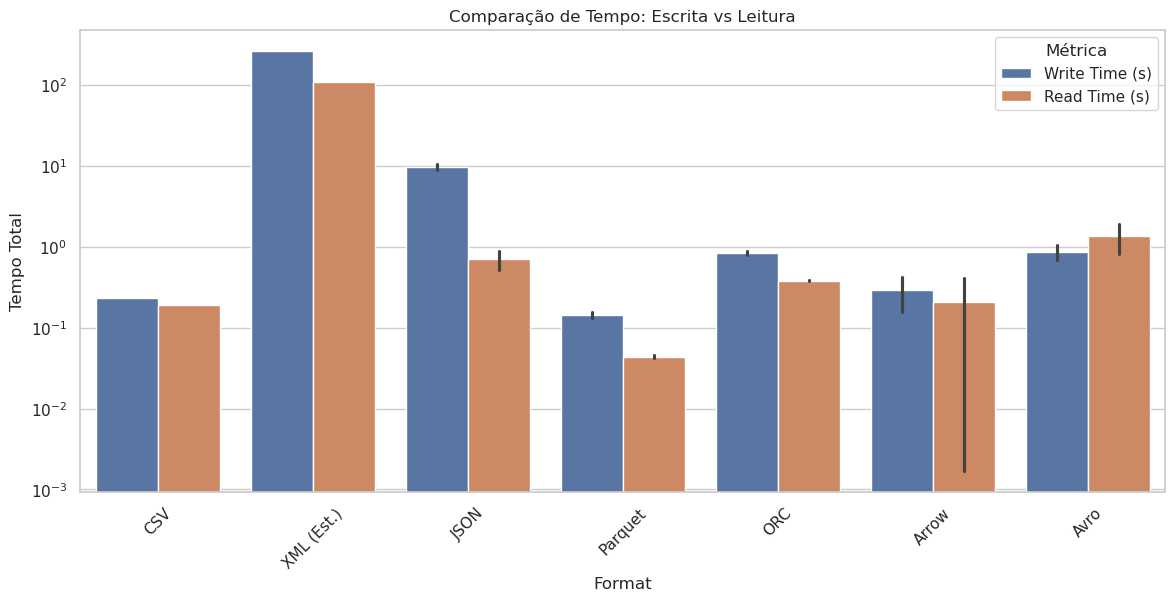

In [20]:
plt.figure(figsize=(14, 6))
metrics_df = df_final.melt(
    id_vars=["Format", "Compression"],
    value_vars=["Write Time (s)", "Read Time (s)"],
    var_name="Métrica",
    value_name="Tempo Total",
)
sns.barplot(data=metrics_df, x="Format", y="Tempo Total", hue="Métrica")
plt.title("Comparação de Tempo: Escrita vs Leitura")
plt.yscale("log")
plt.xticks(rotation=45)
plt.show()

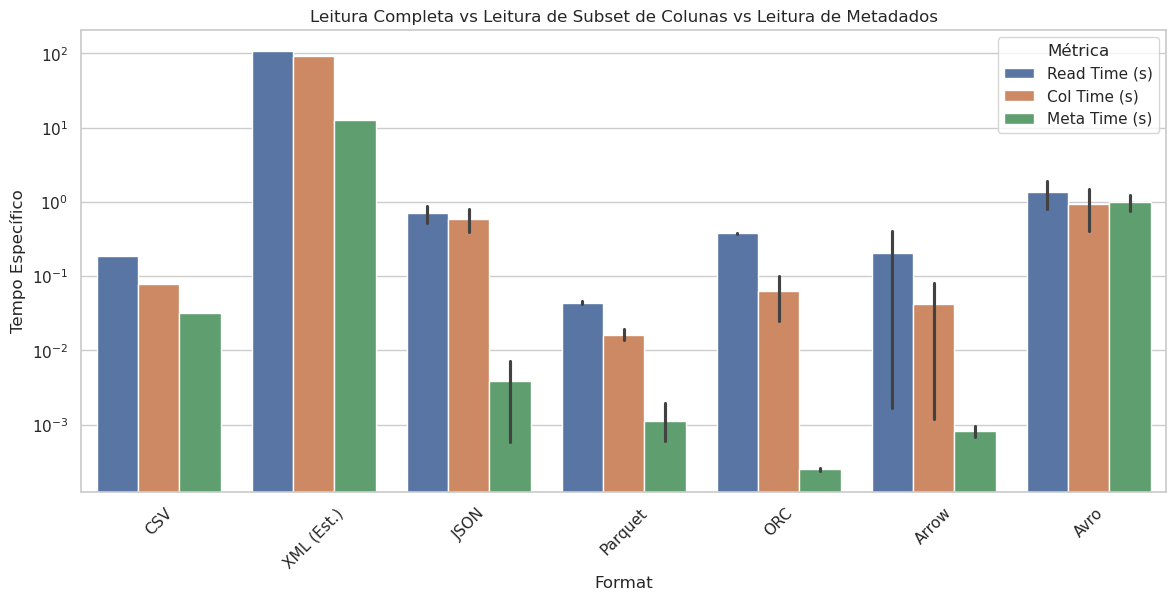

In [21]:
plt.figure(figsize=(14, 6))
read_metrics = df_final.melt(
    id_vars=["Format", "Compression"],
    value_vars=["Read Time (s)", "Col Time (s)", "Meta Time (s)"],
    var_name="Métrica",
    value_name="Tempo Específico",
)
sns.barplot(data=read_metrics, x="Format", y="Tempo Específico", hue="Métrica")
plt.title("Leitura Completa vs Leitura de Subset de Colunas vs Leitura de Metadados")
plt.yscale("log")
plt.xticks(rotation=45)
plt.show()

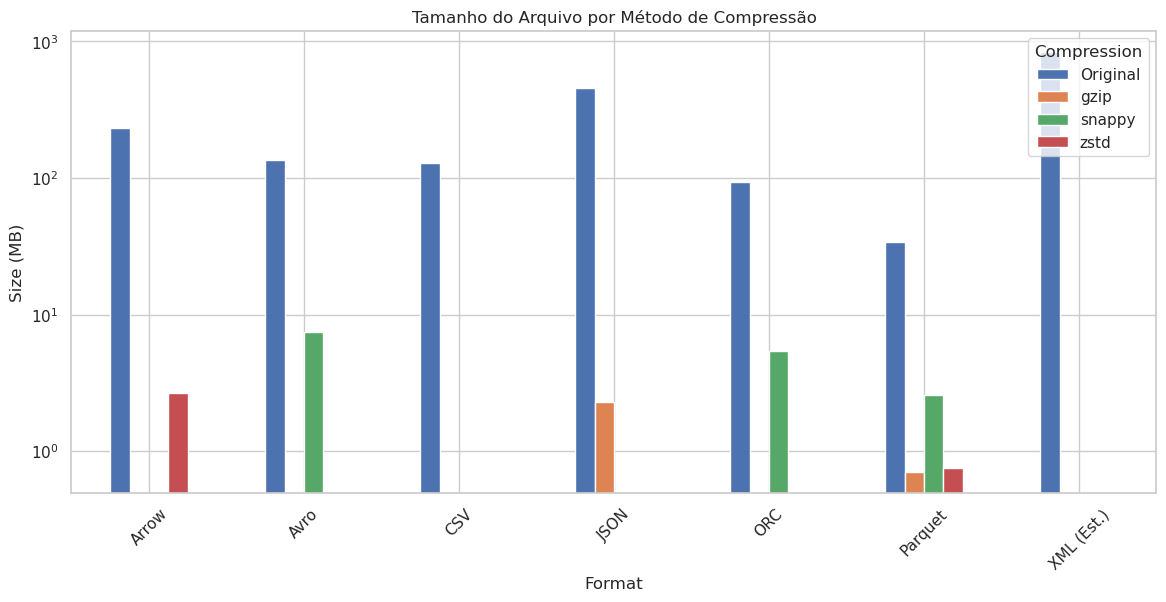

In [22]:
ax = df_final.pivot(index="Format", columns="Compression", values="Size (MB)").plot(
    kind="bar", figsize=(14, 6)
)
plt.title("Tamanho do Arquivo por Método de Compressão")
plt.ylabel("Size (MB)")
plt.yscale("log")
plt.xticks(rotation=45)
plt.show()

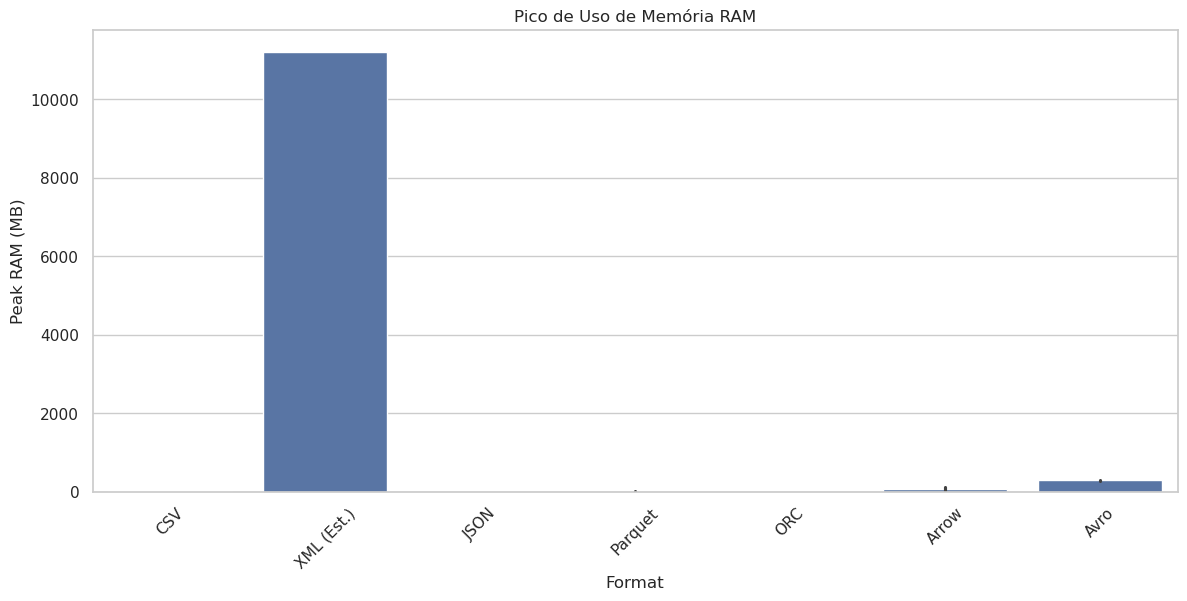

In [23]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_final, x="Format", y="Peak RAM (MB)")
plt.title("Pico de Uso de Memória RAM")
plt.xticks(rotation=45)
plt.show()

In [24]:
print(f"**Tempo Total de Processamento: {time.time() - workflow_start:.2f}s**")

**Tempo Total de Processamento: 70.64s**


**Referências Adicionais & IA:**
- **Parquet:** [Parquet File Format](https://parquet.apache.org/docs/file-format/) | [Parquet Concepts](https://parquet.apache.org/docs/concepts/)
- **ORC:** [ORC Spec v1](https://orc.apache.org/specification/ORCv1/) | [RCFile vs ORC](https://www.bigdatainrealworld.com/rcfile-vs-orc/)
- **Arrow:** [Arrow Columnar Format](https://arrow.apache.org/docs/format/Columnar.html)
- **Avro:** [Especificação Avro](https://avro.apache.org/docs/current/specification/)
- **Uso de IA:** Partes da consolidação teórica e refatoração de formatação deste notebook foram validadas utilizando IA generativa (OpenAI/Copilot) para garantir precisão arquitetônica e fluência de markdown.
